# MLP — Evaluacion de Credito en Fintech

| Campo | Valor |
|:------|:------|
| **Autor** | Borja Mora Mendez |
| **Contacto** | borja.mora.mendez@gmail.com |
| **LinkedIn** | [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez) |
| **Categoria** | Machine Learning > Redes Neuronales > MLP (Clasificacion) |
| **Dataset** | Sintetico (100 solicitantes, 4 variables) |
| **Ultima actualizacion** | Julio 2026 |

## 1. Contexto de negocio

Una fintech de microcreditos rapidos necesita automatizar la decision de
aprobacion/rechazo de solicitudes. Actualmente un analista revisa cada caso
manualmente, lo que genera:

- **Cuellos de botella:** 48h de media hasta la decision vs. competidores que aprueban en minutos.
- **Inconsistencia:** criterios subjetivos que varian entre analistas.
- **Morosidad:** la tasa de impago ronda el 12%, erosionando los margenes.

Pregunta analitica: **podemos predecir si un solicitante devolvera el credito
basandonos en su perfil financiero?**

## 2. Objetivo y justificacion del modelo

El MLP se compara con Regresion Logistica y Random Forest para evaluar si
la complejidad neuronal aporta valor en credit scoring con pocas variables.

| Modelo | Ventaja | Limitacion |
|:-------|:--------|:-----------|
| MLP | Captura no-linealidades | Requiere escalado, menos interpretable |
| Regresion Logistica | Interpretable, standard en banca | Solo lineal |
| Random Forest | Feature importance, robusto | Sin probabilidades calibradas nativas |

In [1]:
# ── Datos ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizacion ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Modelado ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 4. Carga y exploracion inicial

### Diccionario de variables

| Variable | Tipo | Descripcion |
|:---------|:-----|:------------|
| Ingresos_Mensuales | float | Ingresos mensuales en euros |
| Score_Comportamiento | float | Puntuacion de comportamiento crediticio (0-100) |
| Deudas_Activas | int | Numero de deudas activas |
| Aprobado | int (target) | 1 = credito aprobado/devuelto, 0 = rechazado/impagado |

In [2]:
# ── Dataset sintetico ─────────────────────────────────────────────────────────
np.random.seed(42)
n = 100

ingresos = np.round(np.random.normal(2500, 600, n).clip(1000, 10000), 2)
score = np.round(np.random.normal(55, 15, n).clip(10, 95), 1)
deudas = np.random.choice(range(0, 6), n, p=[0.3, 0.3, 0.2, 0.1, 0.07, 0.03])

# Target correlacionado con score y deudas
logit = 0.05 * score - 0.8 * deudas + 0.0005 * ingresos - 3
prob = 1 / (1 + np.exp(-logit))
aprobado = (np.random.random(n) < prob).astype(int)

df = pd.DataFrame({
    "Ingresos_Mensuales": ingresos,
    "Score_Comportamiento": score,
    "Deudas_Activas": deudas,
    "Aprobado": aprobado
})

print(f"Shape: {df.shape}")
print(f"\nDistribucion del target:")
print(df["Aprobado"].value_counts(normalize=True).map(lambda x: f"{x:.1%}"))
print()
print(df.describe().round(1))

Shape: (100, 4)

Distribucion del target:
Aprobado
1    52.0%
0    48.0%
Name: proportion, dtype: object

       Ingresos_Mensuales  Score_Comportamiento  Deudas_Activas  Aprobado
count               100.0                 100.0           100.0     100.0
mean               2438.4                  55.3             1.3       0.5
std                 542.9                  14.3             1.2       0.5
min                1000.0                  26.2             0.0       0.0
25%                2139.5                  43.0             0.0       0.0
50%                2423.8                  56.2             1.0       1.0
75%                2743.6                  63.0             2.0       1.0
max                3611.4                  95.0             5.0       1.0


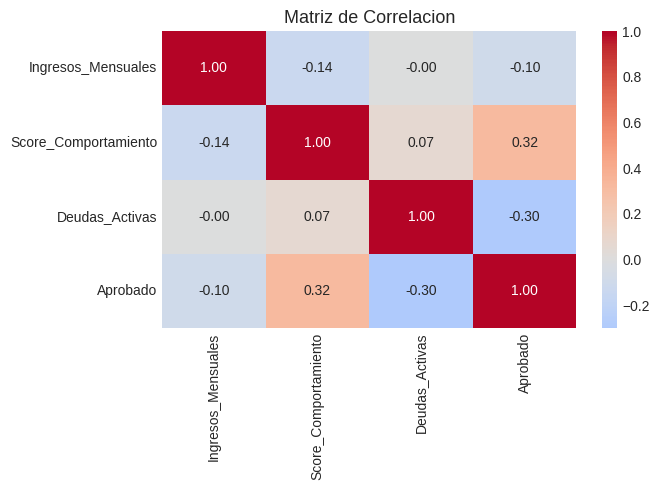

In [3]:
# ── Matriz de correlacion ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de Correlacion", fontsize=13)
plt.tight_layout()
plt.show()

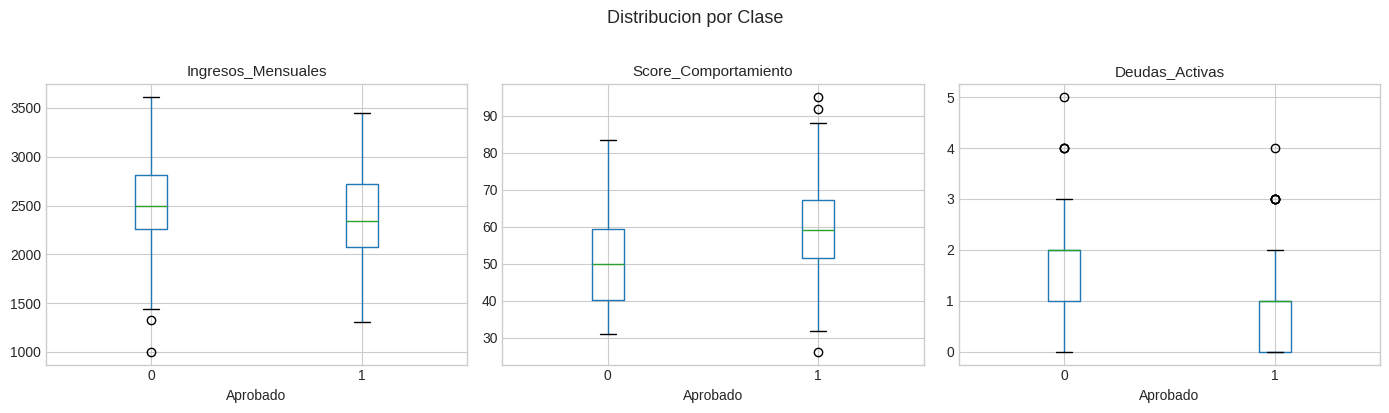

In [4]:
# ── Distribucion por clase ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(["Ingresos_Mensuales", "Score_Comportamiento", "Deudas_Activas"]):
    df.boxplot(column=col, by="Aprobado", ax=axes[i])
    axes[i].set_title(f"{col}", fontsize=11)
    axes[i].set_xlabel("Aprobado")
plt.suptitle("Distribucion por Clase", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Preparacion de datos

In [5]:
# ── Separacion y escalado ─────────────────────────────────────────────────────
X = df[["Ingresos_Mensuales", "Score_Comportamiento", "Deudas_Activas"]]
y = df["Aprobado"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} | Test: {X_test_sc.shape[0]}")

Train: 80 | Test: 20


## 6. Modelo principal: MLP

Arquitectura: 3 capas ocultas (128, 64, 32), ReLU, Adam con early stopping.

In [6]:
# ── MLP ───────────────────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)
mlp.fit(X_train_sc, y_train)
y_pred_mlp = mlp.predict(X_test_sc)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy MLP: {acc_mlp:.1%}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=["Rechazado", "Aprobado"]))

Accuracy MLP: 70.0%

              precision    recall  f1-score   support

   Rechazado       0.70      0.70      0.70        10
    Aprobado       0.70      0.70      0.70        10

    accuracy                           0.70        20
   macro avg       0.70      0.70      0.70        20
weighted avg       0.70      0.70      0.70        20



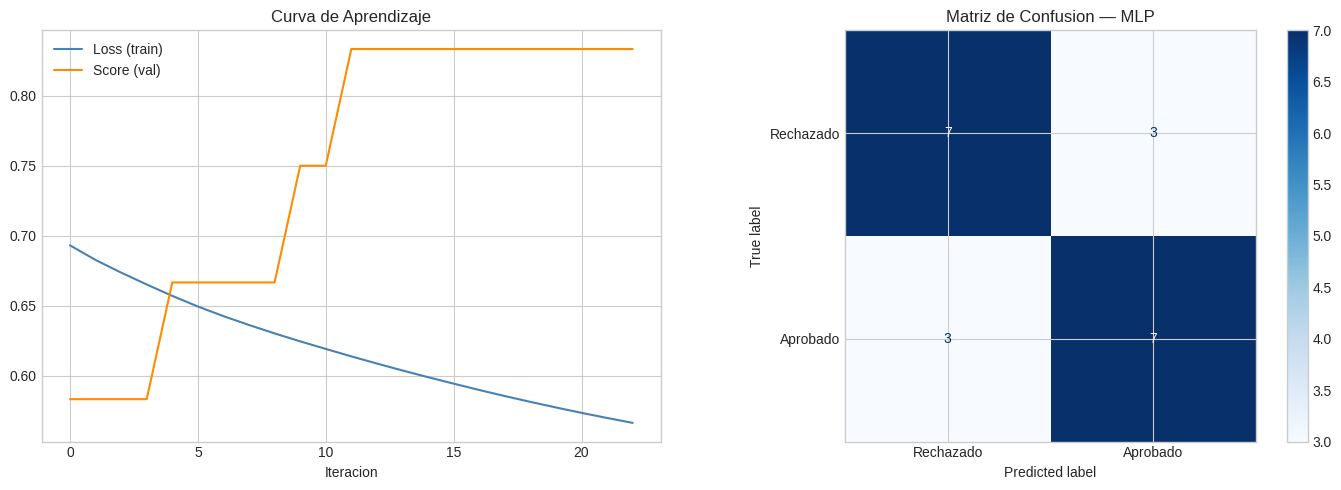

In [7]:
# ── Curva de aprendizaje y confusion ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp.loss_curve_, color="steelblue", label="Loss (train)")
if hasattr(mlp, "validation_scores_"):
    axes[0].plot(mlp.validation_scores_, color="darkorange", label="Score (val)")
axes[0].set_title("Curva de Aprendizaje", fontsize=12)
axes[0].set_xlabel("Iteracion")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp, display_labels=["Rechazado", "Aprobado"],
    cmap="Blues", ax=axes[1]
)
axes[1].set_title("Matriz de Confusion — MLP", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Modelo alternativo: Regresion Logistica

In [8]:
lr = LogisticRegression(random_state=42, max_iter=500)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy Logistic Regression: {acc_lr:.1%}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Rechazado", "Aprobado"]))

Accuracy Logistic Regression: 75.0%

              precision    recall  f1-score   support

   Rechazado       0.69      0.90      0.78        10
    Aprobado       0.86      0.60      0.71        10

    accuracy                           0.75        20
   macro avg       0.77      0.75      0.74        20
weighted avg       0.77      0.75      0.74        20



## 8. Modelo alternativo: Random Forest

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Random Forest: {acc_rf:.1%}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["Rechazado", "Aprobado"]))

Accuracy Random Forest: 85.0%

              precision    recall  f1-score   support

   Rechazado       0.77      1.00      0.87        10
    Aprobado       1.00      0.70      0.82        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



## 9. Curvas ROC comparativas

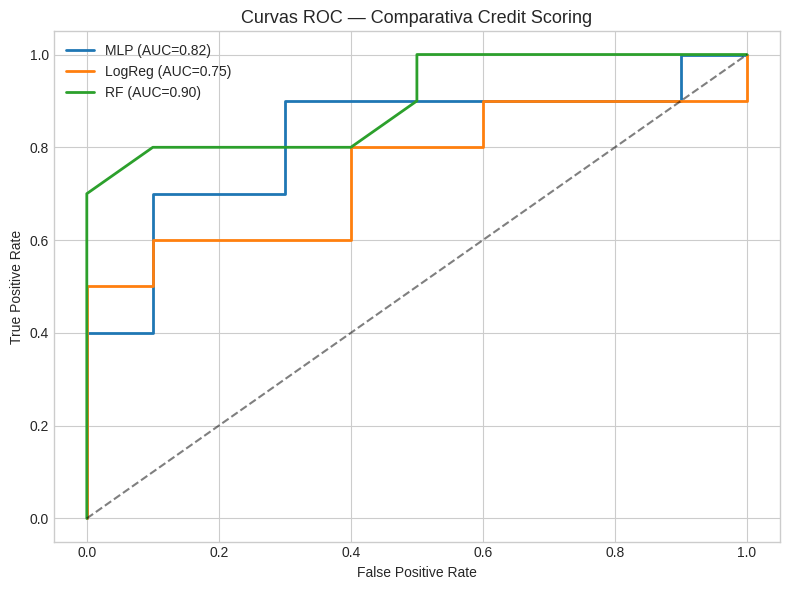

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, model, X_t in [("MLP", mlp, X_test_sc), ("LogReg", lr, X_test_sc), ("RF", rf, X_test)]:
    proba = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("Curvas ROC — Comparativa Credit Scoring", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Tabla comparativa

| Modelo | Accuracy | Interpretabilidad | Uso en banca |
|:-------|:---------|:------------------|:-------------|
| MLP (128,64,32) | Ver resultados | Baja | Requiere explicabilidad adicional (SHAP) |
| Regresion Logistica | Ver resultados | Alta | Standard regulatorio |
| Random Forest | Ver resultados | Media | Aceptable con feature importance |

En credit scoring, la regulacion (EBA, BCE) exige modelos explicables.
La Regresion Logistica sigue siendo el standard de la industria para
decisiones automaticas de credito.

## 11. Insights y recomendaciones accionables

### Hallazgo clave
Con 3 variables y 100 registros, el MLP no supera significativamente a la
Regresion Logistica. El Score_Comportamiento y las Deudas_Activas son los
principales predictores de aprobacion.

### Recomendaciones

**1. Usar LogReg como modelo regulatorio (impacto: alto, esfuerzo: bajo)**
Cumple requisitos de explicabilidad. Los coeficientes se traducen directamente
en reglas de negocio ("cada deuda activa reduce la probabilidad de aprobacion en X%").

**2. MLP como modelo shadow (impacto: medio, esfuerzo: medio)**
Ejecutar el MLP en paralelo sin tomar decisiones. Si consistentemente supera
a LogReg en >3pp de AUC, plantear su uso con capa de explicabilidad SHAP.

**3. Automatizar el scoring en tiempo real (impacto: alto, esfuerzo: medio)**
Integrar predict_proba en la API de la app: aprobacion instantanea si P>0.8,
revision manual si 0.4<P<0.8, rechazo automatico si P<0.4.

## 12. Limitaciones y proximos pasos

### Limitaciones
- Dataset sintetico pequeno: no refleja la complejidad real del credit scoring.
- Sin variables temporales (historial de pagos, tendencia de ingresos).
- Sin validacion cruzada por tamano reducido.

### Proximos pasos
- [ ] Probar con dataset real (Kaggle: Home Credit, Lending Club).
- [ ] Anadir features temporales y categoricas (tipo empleo, sector).
- [ ] Implementar SHAP values para el MLP.
- [ ] Calibrar probabilidades con CalibratedClassifierCV.